# Week 6 — Probing GPT-2's internals

Load GPT-2 (124M params) from HuggingFace →
inspect the parameter breakdown → visualize attention patterns and measure
their rank → analyze the residual stream layer by layer → prune
attention heads and measure impact → explore the embedding space → vary
softmax temperature and observe attention sharpness.



In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from transformers import GPT2LMHeadModel, GPT2Tokenizer

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

%matplotlib inline

Using device: cuda


## Setup — Load GPT-2

GPT-2 small: 124M parameters, 12 layers, 12 heads per layer, $d = 768$,
vocabulary size 50,257. We load the pretrained model and tokenizer from
HuggingFace.

In [ ]:
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2', output_attentions=True).to(device)
model.eval()

print(f"Model: GPT-2 small")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Layers: {model.config.n_layer}")
print(f"Heads: {model.config.n_head}")
print(f"d_model: {model.config.n_embd}")
print(f"Vocab: {model.config.vocab_size}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model: GPT-2 small
Parameters: 124,439,808
Layers: 12
Heads: 12
d_model: 768
Vocab: 50257


## Part 1 — Where do the parameters live?

A transformer has three main components: embeddings, attention, and the
feed-forward network (FFN). Before probing the model's behavior, let's
understand its structure quantitatively.

In [ ]:
# --- Parameter breakdown by component ----------------------------------------
def parameter_breakdown(model):
    '''Count parameters by component type.'''
    counts = {
        'token_embedding': 0,
        'position_embedding': 0,
        'attention': 0,
        'ffn': 0,
        'layernorm': 0,
        'output_head': 0,
    }

    for name, p in model.named_parameters():
        n = p.numel()
        if 'wte' in name:
            counts['token_embedding'] += n
        elif 'wpe' in name:
            counts['position_embedding'] += n
        elif 'attn' in name:
            counts['attention'] += n
        elif 'mlp' in name:
            counts['ffn'] += n
        elif 'ln' in name:
            counts['layernorm'] += n
        elif 'lm_head' in name:
            counts['output_head'] += n
        else:
            print(f"  uncategorized: {name} ({n:,})")

    return counts

counts = parameter_breakdown(model)
total = sum(counts.values())

print(f"Parameter breakdown:")
print(f"  {'Component':<22s} {'Count':>12s} {'Fraction':>10s}")
print(f"  {'─'*46}")
for name, c in counts.items():
    print(f"  {name:<22s} {c:>12,} {c/total:>10.1%}")
print(f"  {'─'*46}")
print(f"  {'Total':<22s} {total:>12,}")

Parameter breakdown:
  Component                     Count   Fraction
  ──────────────────────────────────────────────
  token_embedding          38,597,376      31.0%
  position_embedding          786,432       0.6%
  attention                28,348,416      22.8%
  ffn                      56,669,184      45.5%
  layernorm                    38,400       0.0%
  output_head                       0       0.0%
  ──────────────────────────────────────────────
  Total                   124,439,808


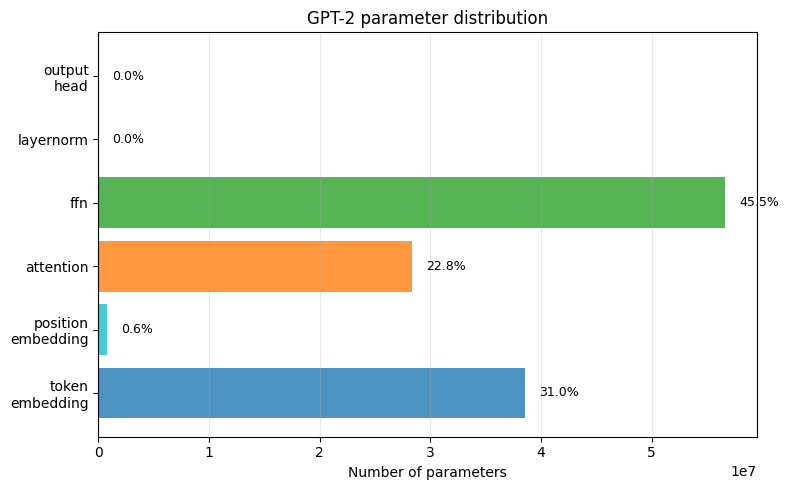

In [ ]:
# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
labels = [k.replace('_', '\n') for k in counts.keys()]
values = list(counts.values())
colors = ['tab:blue', 'tab:cyan', 'tab:orange', 'tab:green', 'tab:gray', 'tab:purple']
ax.barh(labels, values, color=colors, alpha=0.8)
ax.set_xlabel('Number of parameters')
ax.set_title('GPT-2 parameter distribution')
ax.grid(True, alpha=0.3, axis='x')
for i, v in enumerate(values):
    ax.text(v + total*0.01, i, f'{v/total:.1%}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


The FFN dominates — roughly 2× the parameters of attention. The token
embedding is large because the vocabulary is large (50k × 768). Note that
GPT-2 ties the output head weights to the token embedding, so
`output_head` may show 0 (the parameters are shared).
 Attention
*routes* information between positions; the FFN *processes* it.

## Part 2 — Attention patterns and their rank

We feed a sentence through GPT-2, extract the attention matrices from
every layer and head, and analyze them.

### What to look for

Trained attention heads develop characteristic patterns:

- **Positional heads**: attend to the previous token (or a fixed offset)
- **Syntactic heads**: attend to matching brackets, quotes, or delimiters
- **Semantic heads**: attend to content-related tokens
- **Induction heads**: attend to tokens that previously followed the
  current token (crucial for in-context learning)

### The rank question

Each attention matrix $A \in \mathbb{R}^{n \times n}$ has at most rank
$\min(n, d_k)$. But the *effective* rank is often much lower — many
heads produce near-uniform or near-one-hot attention, both of which are
low-rank. This is the Week 3 story applied to attention.

In [ ]:
# --- Run a sentence through GPT-2 and extract attention --------------------
text = "The cat sat on the mat (((fklm.mlkm)))"

inputs = tokenizer(text, return_tensors='pt').to(device)
tokens_str = [tokenizer.decode(t) for t in inputs['input_ids'][0]]

with torch.no_grad():
    # Explicitly request attentions in the forward pass
    outputs = model(**inputs, output_attentions=True)

# Safety check to avoid AttributeError
if outputs.attentions is None:
    raise ValueError("Attentions were not returned. Ensure output_attentions=True is set.")

# outputs.attentions is a tuple of (batch, n_heads, seq_len, seq_len) per layer
attentions = [a.squeeze(0).cpu() for a in outputs.attentions]

n_layers = len(attentions)
n_heads = attentions[0].shape[0]
seq_len = attentions[0].shape[1]

print(f"Input: '{text}'")
print(f"Tokens ({seq_len}): {tokens_str}")
print(f"Attention tensors: {n_layers} layers × {n_heads} heads × "
      f"{seq_len}×{seq_len} matrices")

Input: 'The cat sat on the mat (((fklm.mlkm)))'
Tokens (15): ['The', ' cat', ' sat', ' on', ' the', ' mat', ' ((', '(', 'f', 'kl', 'm', '.', 'ml', 'km', ')))']
Attention tensors: 12 layers × 12 heads × 15×15 matrices


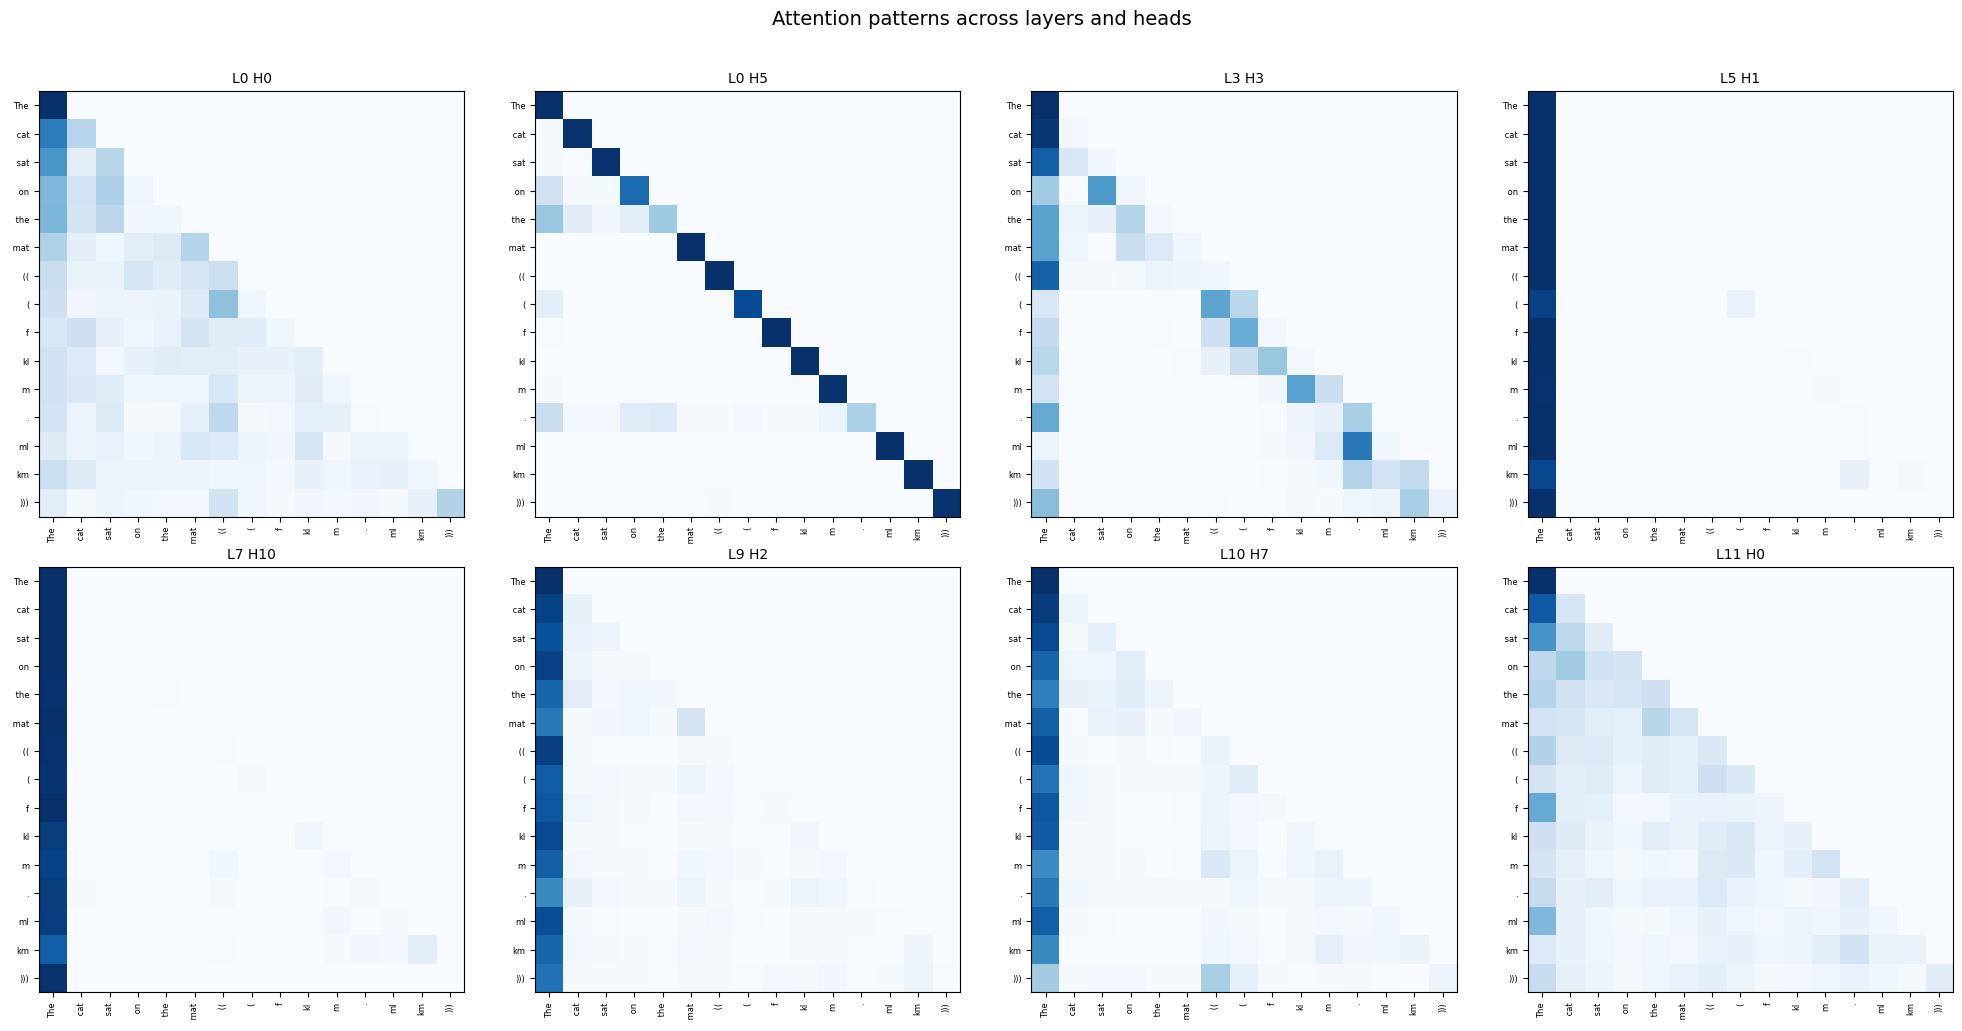

In [ ]:
# --- Visualize attention for selected heads ----------------------------------
# Show 4 heads from different layers to illustrate pattern diversity
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Pick interesting layers (early, middle, late) and heads
selections = [(0, 0), (0, 5), (3, 3), (5, 1),
              (7, 10), (9, 2), (10, 7), (11, 0)]

for idx, (layer, head) in enumerate(selections):
    ax = axes[idx // 4, idx % 4]
    attn = attentions[layer][head].numpy()
    ax.imshow(attn, cmap='Blues')
    ax.set_title(f'L{layer} H{head}', fontsize=10)
    ax.set_xticks(range(seq_len))
    ax.set_xticklabels(tokens_str, rotation=90, fontsize=6)
    ax.set_yticks(range(seq_len))
    ax.set_yticklabels(tokens_str, fontsize=6)

plt.suptitle('Attention patterns across layers and heads', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

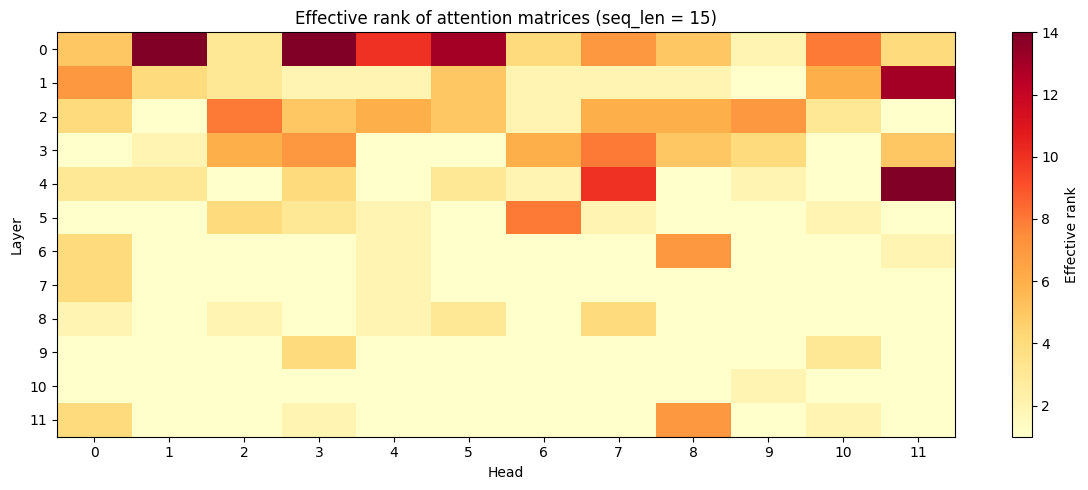

Effective rank statistics (out of max 15):
  Mean: 2.9
  Median: 2.0
  Min: 1, Max: 14
  Fraction with rank ≤ 3: 70.8%


In [ ]:
# --- Effective rank of attention matrices ------------------------------------
def effective_rank(A, threshold=0.95):
    '''Effective rank: smallest k capturing threshold of squared singular values.'''
    S = torch.linalg.svdvals(A)
    var_exp = torch.cumsum(S**2, 0) / (S**2).sum()
    return int(torch.searchsorted(var_exp, threshold).item()) + 1

# Compute effective rank for every head in every layer
ranks = np.zeros((n_layers, n_heads))
for layer in range(n_layers):
    for head in range(n_heads):
        ranks[layer, head] = effective_rank(attentions[layer][head])

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(ranks, cmap='YlOrRd', aspect='auto')
ax.set_xlabel('Head'); ax.set_ylabel('Layer')
ax.set_title(f'Effective rank of attention matrices (seq_len = {seq_len})')
ax.set_xticks(range(n_heads)); ax.set_yticks(range(n_layers))
plt.colorbar(im, ax=ax, label='Effective rank')
plt.tight_layout()
plt.show()

print(f"Effective rank statistics (out of max {seq_len}):")
print(f"  Mean: {ranks.mean():.1f}")
print(f"  Median: {np.median(ranks):.1f}")
print(f"  Min: {ranks.min():.0f}, Max: {ranks.max():.0f}")
print(f"  Fraction with rank ≤ 3: {(ranks <= 3).mean():.1%}")


### Attention patterns

Different heads learn qualitatively different patterns. Common types
visible in GPT-2:

- **Previous-token heads**: strong diagonal offset by 1 (each token
  attends to its predecessor)
- **Broad heads**: nearly uniform attention (aggregate context)
- **Sparse heads**: attend to one or two specific positions

###Possible interpetations:
L0 H5 looks like a Positional head. Very strong diagonal pattern. It mostly attends to the same/nearby position.

L9 H2: Possible semantic/context head. It attends to scattered earlier tokens, not just position. Could be content/context aggregation.
L11 H0: Broad context/semantic head. It attends over many earlier tokens rather than a fixed offset. This is the best candidate here for a semantic/context head.

### Low-rank attention

Most attention matrices have effective rank well below the sequence length.
This means the attention pattern compresses the $n$ positions into a
few effective "clusters." The model doesn't use the full capacity of the
$n \times n$ attention matrix — most of the structure is redundant.

The hidden features had effective rank $\ll$
nominal width. Attention matrices show the same compression — the model
operates in a low-dimensional subspace of possible attention patterns.

## Part 3 — The residual stream across layers

The "residual stream" is the sequence of hidden states flowing through
the transformer. At each layer, the MHA and FFN add their contributions
to this stream (via residual connections).

We extract the hidden states at every layer and compute their SVD — the
same analysis we did on MLP hidden features in Week 3, but now on a
pretrained transformer.



### Residual Stream in Transformers

The residual stream is the main hidden representation passed through the Transformer.

For token position (t):

$$
x_t^{(0)} = e_{\text{token}t} + e{\text{pos}t}
$$

Each layer reads from the residual stream, computes updates, and adds them back:

$
\tilde{x}^{(\ell)} = x^{(\ell)} + \mathrm{Attn}^{(\ell)}(\mathrm{LN}(x^{(\ell)}))
$

$$
x^{(\ell+1)} = \tilde{x}^{(\ell)} + \mathrm{MLP}^{(\ell)}(\mathrm{LN}(\tilde{x}^{(\ell)}))
$$

Equivalently:

$$
x^{(\ell+1)}
=
x^{(\ell)}
+
\Delta{\text{attn}}^{(\ell)}
+
\Delta_{\text{mlp}}^{(\ell)}.
$$

Thus, the residual stream starts from token + positional embeddings and is updated additively by attention heads and MLPs across layers.

The final logits are usually computed as:

$$
\mathrm{logits}_t = \mathrm{LN}(x_t^{(L)}) W_U.
$$

Interpretation: the residual stream is a shared workspace where embeddings, attention heads, and MLPs write information used for next-token prediction.

In [ ]:
# --- Extract hidden states at every layer ------------------------------------
with torch.no_grad():
    outputs = model(**inputs, output_hidden_states=True)

# hidden_states is a tuple: (embedding_output, after_layer_0, ..., after_layer_11)
hidden_states = [h.squeeze(0).cpu().numpy() for h in outputs.hidden_states]

print(f"Hidden states: {len(hidden_states)} tensors (embedding + {n_layers} layers)")
print(f"Each: {hidden_states[0].shape}  (seq_len × d_model)")

Hidden states: 13 tensors (embedding + 12 layers)
Each: (14, 768)  (seq_len × d_model)


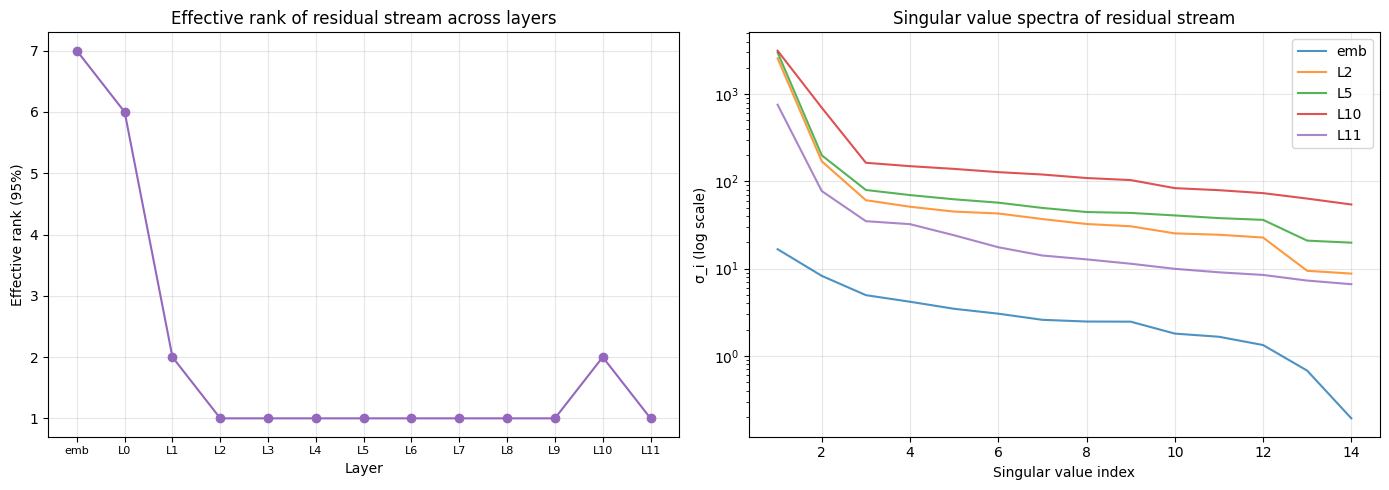

Effective rank across layers:
  embedding   : eff. rank = 7
  layer 0     : eff. rank = 6
  layer 1     : eff. rank = 2
  layer 2     : eff. rank = 1
  layer 3     : eff. rank = 1
  layer 4     : eff. rank = 1
  layer 5     : eff. rank = 1
  layer 6     : eff. rank = 1
  layer 7     : eff. rank = 1
  layer 8     : eff. rank = 1
  layer 9     : eff. rank = 1
  layer 10    : eff. rank = 2
  layer 11    : eff. rank = 1


In [ ]:
# --- Effective rank of the residual stream at each layer ---------------------
residual_ranks = []
residual_spectra = []

for i, h in enumerate(hidden_states):
    U, S, Vt = np.linalg.svd(h, full_matrices=False)
    var_exp = np.cumsum(S**2) / np.sum(S**2)
    eff_r = int(np.searchsorted(var_exp, 0.95)) + 1
    residual_ranks.append(eff_r)
    residual_spectra.append(S)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: effective rank across layers
ax = axes[0]
layer_labels = ['emb'] + [f'L{i}' for i in range(n_layers)]
ax.plot(range(len(residual_ranks)), residual_ranks, 'o-',
        color='tab:purple', markersize=6)
ax.set_xticks(range(len(residual_ranks)))
ax.set_xticklabels(layer_labels, fontsize=8)
ax.set_xlabel('Layer'); ax.set_ylabel('Effective rank (95%)')
ax.set_title('Effective rank of residual stream across layers')
ax.grid(True, alpha=0.3)

# Right: singular value spectra for selected layers
ax = axes[1]
for i in [0, 3, 6, 11, 12]:
    label = 'emb' if i == 0 else f'L{i-1}' if i <= 12 else f'final'
    if i < len(residual_spectra):
        ax.semilogy(range(1, len(residual_spectra[i])+1),
                    residual_spectra[i], '-', label=label, alpha=0.8)
ax.set_xlabel('Singular value index'); ax.set_ylabel('σ_i (log scale)')
ax.set_title('Singular value spectra of residual stream')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Effective rank across layers:")
for i, r in enumerate(residual_ranks):
    label = 'embedding' if i == 0 else f'layer {i-1}'
    print(f"  {label:12s}: eff. rank = {r}")


### How the residual stream evolves

The effective rank of the residual stream reveals how the transformer
processes information across layers:

- **Early layers**: the residual stream has higher effective rank — the
  representation is distributed across many dimensions.
- **Later layers**: the rank may decrease as the model focuses on the
  specific features needed for the next-token prediction.

This is the same compression story as Week 3 (MLP hidden features), but
now across the depth of a 12-layer transformer instead of a 2-layer MLP.


Each layer reads from and writes to the residual stream. The attention
layer moves information between positions; the FFN transforms it. The
SVD reveals which dimensions of the 768-dim residual are actually used
at each stage  and many are not.

## Part 4 — Head importance and pruning

If many attention heads have low-rank patterns, some must be redundant.
Can we remove heads without hurting performance?

We measure head importance by **zeroing out** each head one at a time and
measuring the change in the model's output (cross-entropy loss on the
input text). Heads that cause a large loss increase when removed are
important; heads that barely change the loss are prunable.

In [ ]:
# --- Measure head importance by ablation -------------------------------------
def measure_head_importance(model, inputs, tokenizer):
    '''Zero out each head one at a time and measure loss change.'''
    # Baseline loss
    with torch.no_grad():
        outputs_base = model(**inputs, labels=inputs['input_ids'])
        base_loss = outputs_base.loss.item()

    n_layers = model.config.n_layer
    n_heads = model.config.n_head
    importance = np.zeros((n_layers, n_heads))

    for layer_idx in range(n_layers):
        attn_module = model.transformer.h[layer_idx].attn

        for head_idx in range(n_heads):
            # Save original weights
            d = model.config.n_embd
            dk = d // n_heads
            start = head_idx * dk
            end = start + dk

            # Zero out this head's output projection
            original_weight = attn_module.c_proj.weight.data[:, start:end].clone()
            attn_module.c_proj.weight.data[:, start:end] = 0

            with torch.no_grad():
                outputs_ablated = model(**inputs, labels=inputs['input_ids'])
                ablated_loss = outputs_ablated.loss.item()

            importance[layer_idx, head_idx] = ablated_loss - base_loss

            # Restore
            attn_module.c_proj.weight.data[:, start:end] = original_weight

    return importance, base_loss

# Use a longer text for more stable loss estimates
text_long = ("The transformer architecture has revolutionized natural language "
             "processing. Self-attention allows each token to attend to every "
             "other token in the sequence, enabling the model to capture long-range "
             "dependencies that recurrent networks struggle with.")
inputs_long = tokenizer(text_long, return_tensors='pt').to(device)

print("Measuring head importance (this may take a minute)...")
importance, base_loss = measure_head_importance(model, inputs_long, tokenizer)
print(f"Base loss: {base_loss:.4f}")

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Measuring head importance (this may take a minute)...
Base loss: 4.2909


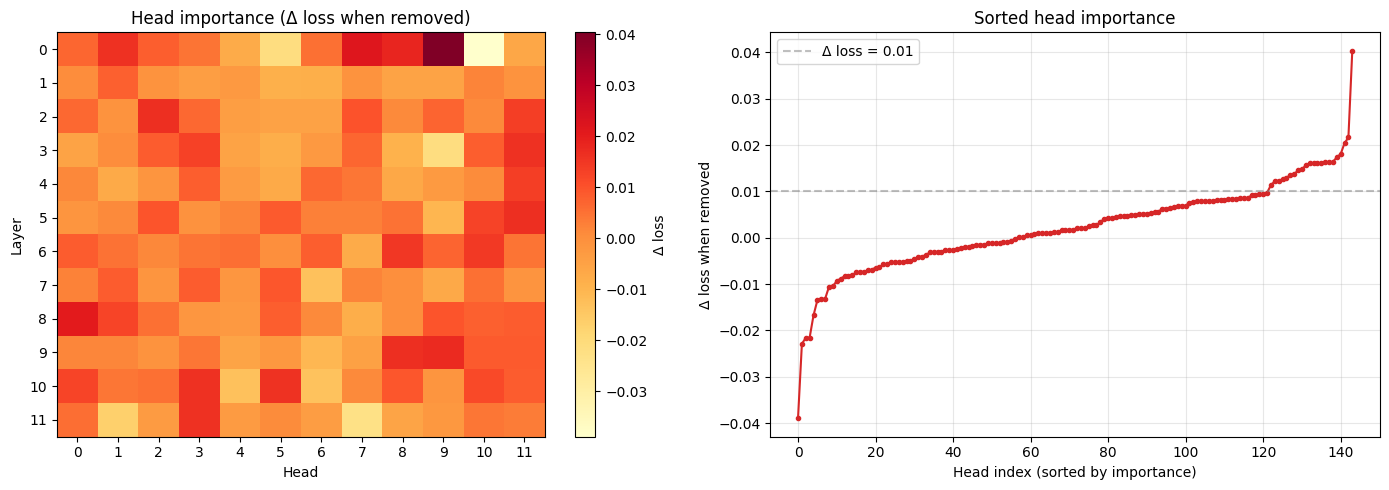

Heads with Δ loss < 0.01: 122 / 144 (85% prunable)
Most important: Layer 0, Head 9 (Δ loss = 0.0403)
Least important: Layer 0, Head 10 (Δ loss = -0.0390)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: heatmap of importance
ax = axes[0]
im = ax.imshow(importance, cmap='YlOrRd', aspect='auto')
ax.set_xlabel('Head'); ax.set_ylabel('Layer')
ax.set_title('Head importance (Δ loss when removed)')
ax.set_xticks(range(n_heads)); ax.set_yticks(range(n_layers))
plt.colorbar(im, ax=ax, label='Δ loss')

# Right: sorted importance — how many heads can be pruned?
ax = axes[1]
sorted_imp = np.sort(importance.flatten())
ax.plot(sorted_imp, 'o-', markersize=3, color='tab:red')
ax.axhline(0.01, color='gray', linestyle='--', alpha=0.5, label='Δ loss = 0.01')
ax.set_xlabel('Head index (sorted by importance)')
ax.set_ylabel('Δ loss when removed')
ax.set_title('Sorted head importance')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Count prunable heads
threshold = 0.01
n_prunable = (importance.flatten() < threshold).sum()
total_heads = n_layers * n_heads
print(f"Heads with Δ loss < {threshold}: {n_prunable} / {total_heads} "
      f"({n_prunable/total_heads:.0%} prunable)")

# Most and least important heads
flat = importance.flatten()
most_idx = np.unravel_index(flat.argmax(), importance.shape)
least_idx = np.unravel_index(flat.argmin(), importance.shape)
print(f"Most important: Layer {most_idx[0]}, Head {most_idx[1]} "
      f"(Δ loss = {importance[most_idx]:.4f})")
print(f"Least important: Layer {least_idx[0]}, Head {least_idx[1]} "
      f"(Δ loss = {importance[least_idx]:.4f})")


### Many heads are prunable

A significant fraction of heads can be removed with negligible loss
increase. This confirms what the rank analysis in Part 2 suggested:
low-rank attention patterns are often redundant — they don't carry
unique information.

### Connection to the course

- **Week 3**: hidden features had effective rank $\ll$ width — the
  model is overparameterized. Same here: many heads are unused capacity.
- **Week 4**: the low-rank Jacobian meant the network is sensitive to
  only a few input directions. Similarly, only a few attention heads
  carry the critical routing information.


Many heads can
be zeroed out. The key questions are: which heads to prune (importance
scoring), and how much can you prune before quality degrades (typically
20–40% of heads in GPT-2).

## Part 5 — The embedding space

The token embedding matrix $E \in \mathbb{R}^{V \times d}$ maps each of
the 50,257 tokens to a 768-dimensional vector. What structure does this
space have?

In [ ]:
# --- Analyze the token embedding matrix --------------------------------------
E = model.transformer.wte.weight.detach().cpu()   # (50257, 768)
print(f"Token embedding matrix: {E.shape}")

# SVD — effective rank
U_e, S_e, Vt_e = torch.linalg.svd(E, full_matrices=False)
var_exp = torch.cumsum(S_e**2, 0) / (S_e**2).sum()
eff_rank_emb = int(torch.searchsorted(var_exp, 0.95).item()) + 1
print(f"Effective rank (95%): {eff_rank_emb} (out of {E.shape[1]})")

Token embedding matrix: torch.Size([50257, 768])
Effective rank (95%): 604 (out of 768)


In [ ]:
# --- Nearest neighbors in embedding space ------------------------------------
def nearest_neighbors(token_str, E, tokenizer, k=10):
    '''Find the k nearest tokens to the given token in embedding space.'''
    tok_id = tokenizer.encode(token_str)
    if len(tok_id) != 1:
        # Try with space prefix
        tok_id = tokenizer.encode(' ' + token_str)
    if len(tok_id) != 1:
        print(f"'{token_str}' tokenizes to multiple tokens, skipping")
        return
    tok_id = tok_id[0]

    vec = E[tok_id]
    # Cosine similarity to all tokens
    E_norm = E / (E.norm(dim=1, keepdim=True) + 1e-10)
    v_norm = vec / (vec.norm() + 1e-10)
    sims = E_norm @ v_norm

    topk = torch.topk(sims, k+1)
    print(f"Nearest neighbors of '{token_str}' (token {tok_id}):")
    for i, (sim, idx) in enumerate(zip(topk.values[1:], topk.indices[1:])):
        decoded = tokenizer.decode([idx.item()])
        print(f"  {i+1:2d}. '{decoded}' (cos sim = {sim.item():.4f})")
    print()

for word in ['king', 'cat', 'Python', 'happy', 'Paris']:
    nearest_neighbors(word, E, tokenizer)

Nearest neighbors of 'king' (token 3364):
   1. 'ked' (cos sim = 0.6833)
   2. 'KING' (cos sim = 0.5702)
   3. 'kers' (cos sim = 0.5579)
   4. 'King' (cos sim = 0.5314)
   5. 'ker' (cos sim = 0.5290)
   6. 'ks' (cos sim = 0.5084)
   7. 'ken' (cos sim = 0.4731)
   8. 'kes' (cos sim = 0.4595)
   9. 'ky' (cos sim = 0.4561)
  10. 'k' (cos sim = 0.4404)

Nearest neighbors of 'cat' (token 9246):
   1. 'cats' (cos sim = 0.6948)
   2. 'Cat' (cos sim = 0.6918)
   3. ' cat' (cos sim = 0.6032)
   4. ' Cat' (cos sim = 0.5690)
   5. ' cats' (cos sim = 0.4907)
   6. ' CAT' (cos sim = 0.4569)
   7. ' catcher' (cos sim = 0.4475)
   8. ' Cats' (cos sim = 0.4383)
   9. 'catching' (cos sim = 0.4216)
  10. 'cow' (cos sim = 0.3972)

Nearest neighbors of 'Python' (token 37906):
   1. ' Python' (cos sim = 0.7640)
   2. 'python' (cos sim = 0.7105)
   3. ' python' (cos sim = 0.6737)
   4. ' Django' (cos sim = 0.5460)
   5. 'ython' (cos sim = 0.5346)
   6. 'Ruby' (cos sim = 0.5299)
   7. '�' (cos sim = 0.5286)


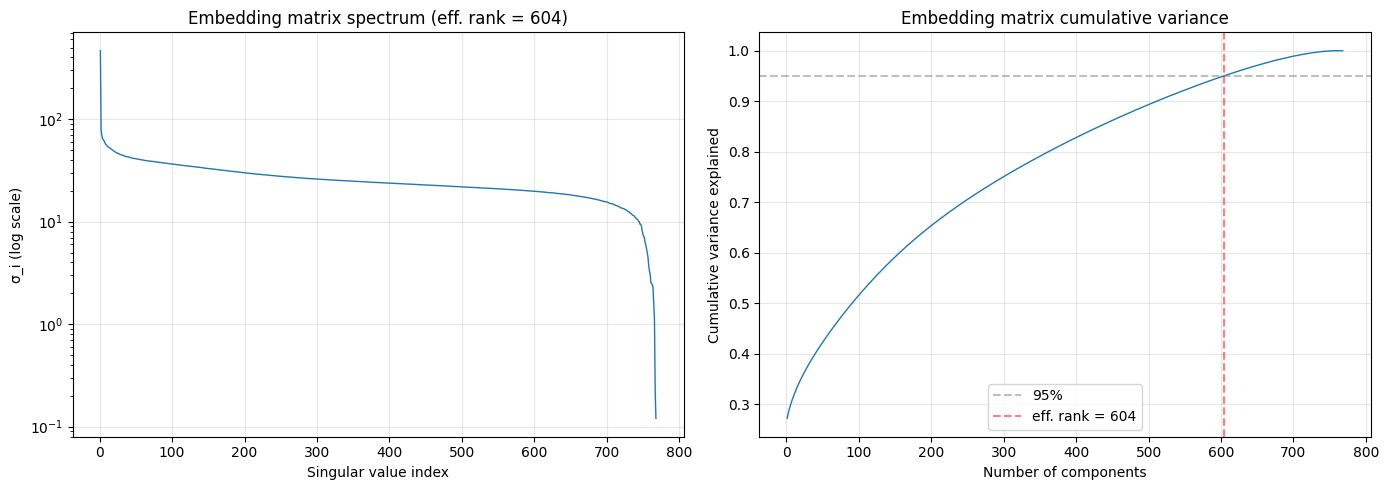

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: singular value spectrum of embedding matrix
ax = axes[0]
ax.semilogy(range(1, len(S_e)+1), S_e.numpy(), '-', color='tab:blue', linewidth=1)
ax.set_xlabel('Singular value index')
ax.set_ylabel('σ_i (log scale)')
ax.set_title(f'Embedding matrix spectrum (eff. rank = {eff_rank_emb})')
ax.grid(True, alpha=0.3)

# Right: cumulative variance
ax = axes[1]
ax.plot(range(1, len(var_exp)+1), var_exp.numpy(), '-', color='tab:blue', linewidth=1)
ax.axhline(0.95, color='gray', linestyle='--', alpha=0.5, label='95%')
ax.axvline(eff_rank_emb, color='red', linestyle='--', alpha=0.5,
           label=f'eff. rank = {eff_rank_emb}')
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative variance explained')
ax.set_title('Embedding matrix cumulative variance')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Embedding space geometry

The embedding matrix has effective rank well below 768 — the 50k tokens
live in a lower-dimensional submanifold of the embedding space. This is
consistent with the linguistic intuition: words fall into a manageable
number of semantic/syntactic categories, not 768 independent dimensions.

Nearest neighbors show semantic clustering: "king" is near other royalty
terms, "cat" near animals, "Paris" near cities. The embedding has
learned meaningful structure from the language modeling objective alone.


 In Week 3, the MLP's hidden features
occupied a low-rank subspace. Here, the vocabulary occupies a low-rank
subspace of the embedding space. Low-rank structure is ubiquitous in
trained neural networks. This is the foundation for LoRA (Week 7).

## Part 6 — Softmax temperature and attention sharpness

The standard attention uses $\text{softmax}(QK^\top / \sqrt{d_k})$. The
$\sqrt{d_k}$ is a specific choice of **temperature**. What happens if we
change it?

$$
A(T) = \text{softmax}\!\left(\frac{QK^\top}{T}\right)
$$

- $T \to 0$: hard attention — all mass on one token (argmax)
- $T = \sqrt{d_k}$: standard attention
- $T \to \infty$: uniform attention — every token gets equal weight

This connects to the entropy of the attention distribution: low $T$
produces low-entropy (peaked) attention, high $T$ produces high-entropy
(spread) attention.

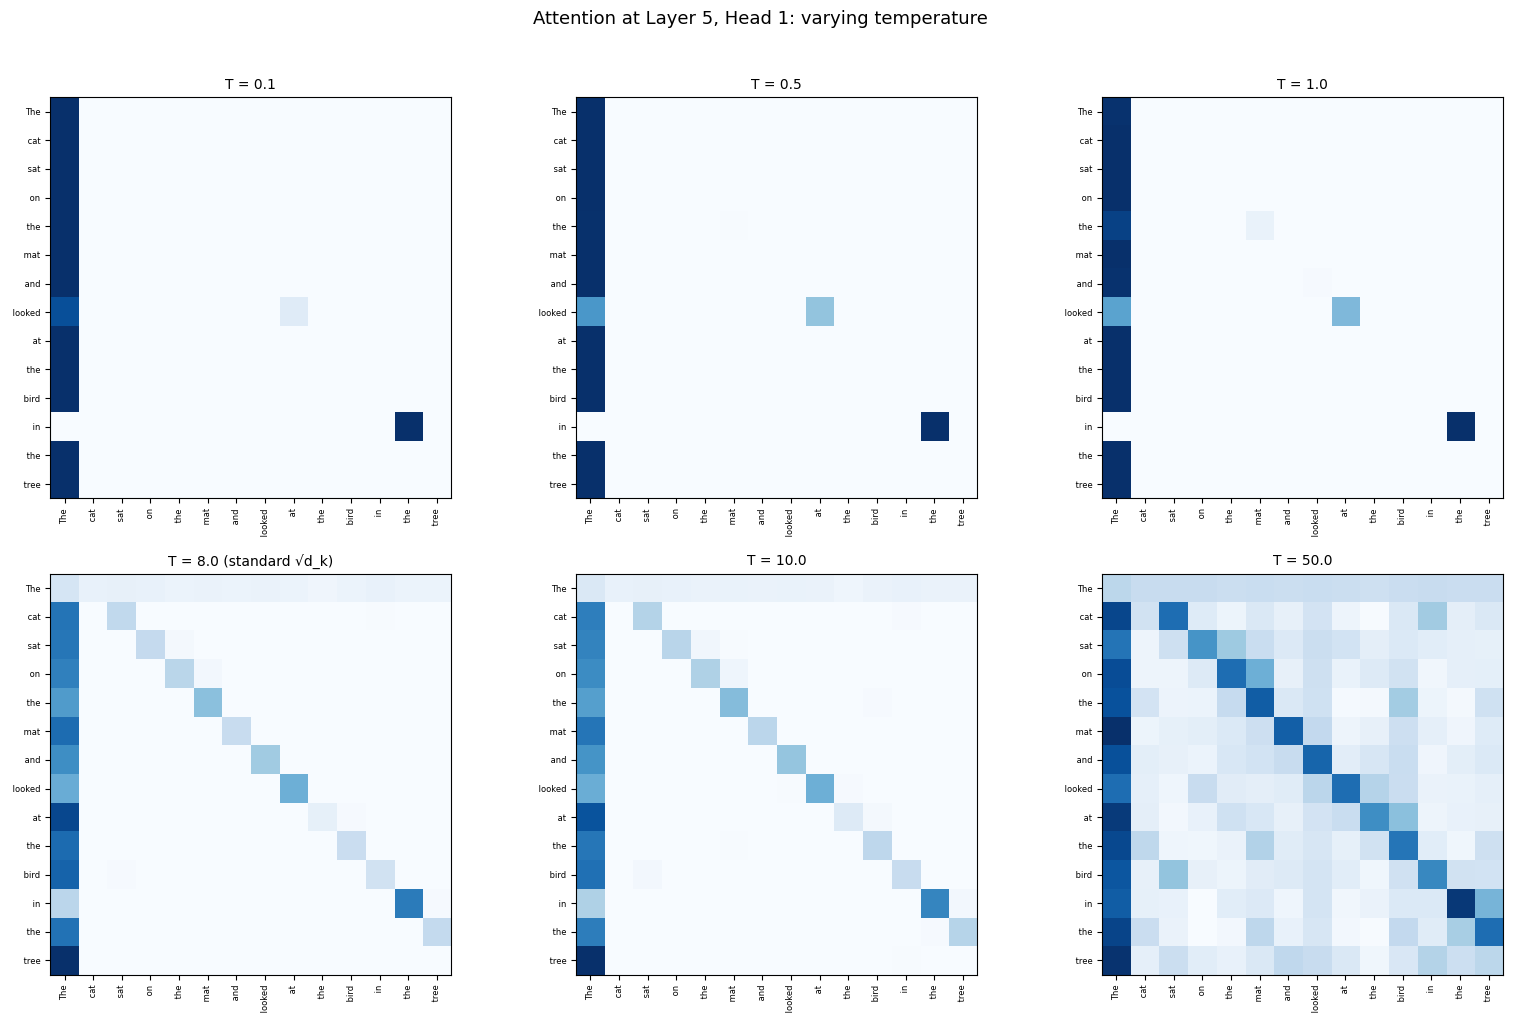

In [ ]:
# --- Temperature experiment on a single head ---------------------------------
# Extract raw attention scores (before softmax) from one layer/head
# We need to hook into the attention computation
layer_idx, head_idx = 5, 1    # pick a head

# Get Q, K for this head
attn_module = model.transformer.h[layer_idx].attn
d_model = model.config.n_embd
n_head = model.config.n_head
dk = d_model // n_head

with torch.no_grad():
    hidden = model.transformer.wte(inputs['input_ids']) + \
             model.transformer.wpe(torch.arange(inputs['input_ids'].shape[1], device=device))
    # Pass through earlier layers
    for i in range(layer_idx):
        block_out = model.transformer.h[i](hidden)
        hidden = block_out[0]

    # Get Q, K from the target layer's attention
    qkv = attn_module.c_attn(model.transformer.h[layer_idx].ln_1(hidden))
    Q, K, V = qkv.split(d_model, dim=-1)

    # Extract the specific head
    Q_h = Q[0, :, head_idx*dk:(head_idx+1)*dk]   # (seq_len, dk)
    K_h = K[0, :, head_idx*dk:(head_idx+1)*dk]

    # Raw scores
    scores = Q_h @ K_h.T    # (seq_len, seq_len)

# Apply softmax at different temperatures
temperatures = [0.1, 0.5, 1.0, float(dk)**0.5, 10.0, 50.0]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for idx, T in enumerate(temperatures):
    ax = axes[idx // 3, idx % 3]
    attn_T = F.softmax(scores / T, dim=-1).cpu().numpy()
    ax.imshow(attn_T, cmap='Blues')
    ax.set_title(f'T = {T:.1f}' + (' (standard √d_k)' if abs(T - dk**0.5) < 0.1 else ''),
                fontsize=10)
    ax.set_xticks(range(seq_len))
    ax.set_xticklabels(tokens_str, rotation=90, fontsize=6)
    ax.set_yticks(range(seq_len))
    ax.set_yticklabels(tokens_str, fontsize=6)

plt.suptitle(f'Attention at Layer {layer_idx}, Head {head_idx}: varying temperature',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

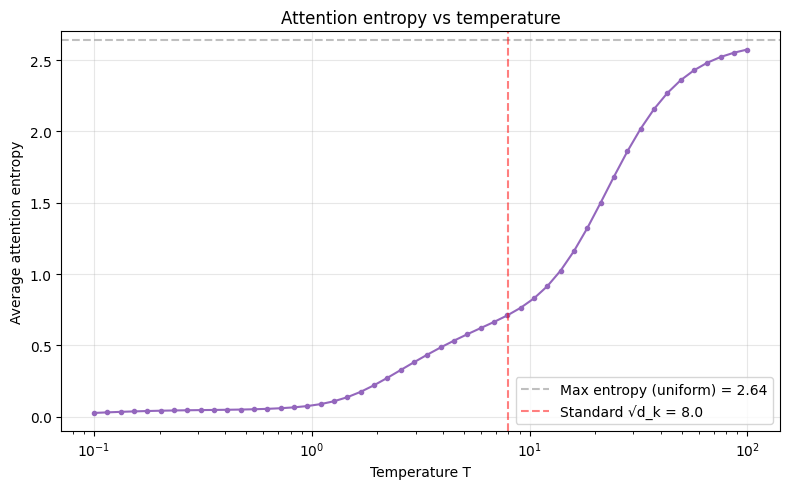

In [ ]:
# --- Entropy of attention distributions across temperatures -----------------
entropies = []
for T in np.logspace(-1, 2, 50):
    attn_T = F.softmax(scores / T, dim=-1)
    # Average entropy across query positions
    H = -(attn_T * torch.log(attn_T + 1e-10)).sum(dim=-1).mean().item()
    entropies.append((T, H))

T_vals, H_vals = zip(*entropies)
max_entropy = np.log(seq_len)

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(T_vals, H_vals, 'o-', markersize=3, color='tab:purple')
ax.axhline(max_entropy, color='gray', linestyle='--', alpha=0.5,
           label=f'Max entropy (uniform) = {max_entropy:.2f}')
ax.axvline(dk**0.5, color='red', linestyle='--', alpha=0.5,
           label=f'Standard √d_k = {dk**0.5:.1f}')
ax.set_xlabel('Temperature T'); ax.set_ylabel('Average attention entropy')
ax.set_title('Attention entropy vs temperature')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Temperature controls the attention sharpness

Low temperature → peaked attention (attends to one or two tokens) →
low entropy. High temperature → uniform attention (attends to everything
equally) → high entropy (= $\log n$).

The standard $\sqrt{d_k}$ scaling puts us at a moderate temperature where
attention is neither too peaked nor too uniform. This was the design
choice in "Attention Is All You Need" and the numerical motivation
(preventing softmax saturation for large $d_k$) was derived in the
instructor prep notebook.


At inference time, the generation temperature serves a similar role —
controlling how peaked or spread the *output* distribution is. Low
temperature → deterministic, repetitive text. High temperature → diverse
but potentially incoherent text. The $\sqrt{d_k}$ in attention and the
generation temperature are the same mathematical mechanism applied at
different points in the model.

## Final observations

**Q1.** Most parameters live in the FFN, not attention. Why does
"attention is all you need" focus on attention?

> The paper's contribution was the attention *mechanism* as a replacement
> for recurrence — it enabled parallel processing of sequences. The FFN
> was already known (it's just an MLP applied per-position). The novelty
> was in the routing, not the processing.

**Q2.** Many attention heads are low-rank and prunable. Why does the model
learn redundant heads?

> Overparameterization helps optimization — gradient descent finds
> solutions more easily in a larger space. The model doesn't need all
> heads at inference, but it benefits from having them during training.
> This is analogous to the MLP in Week 3 having effective rank 4 in a
> 16-dim hidden layer.

**Q3.** The residual stream's effective rank changes across layers.
What does this tell you about how the model processes information?

> Early layers build a broad representation (higher rank); later layers
> specialize toward prediction (potentially lower rank). The residual
> stream is a shared workspace — each layer reads and writes to it, and
> the SVD reveals which dimensions are active at each stage.

**Q4.** You varied the softmax temperature. How does this connect to
the $\sqrt{d_k}$ scaling?

> The $\sqrt{d_k}$ scaling is a temperature of $T = \sqrt{d_k}$. It
> normalizes the variance of the dot-product scores to ~1, keeping
> softmax in its non-saturated regime. Too low (no scaling) → attention
> collapses to argmax. Too high → uniform attention.

**Q5.** The token embedding has low effective rank. What does this imply
for LoRA (Week 7 preview)?

> If the embedding occupies a low-rank subspace, then *updates* to the
> embedding during fine-tuning are also likely low-rank — you're adjusting
> positions within an already low-dimensional manifold. LoRA exploits this
> by parameterizing weight updates as low-rank matrices $\Delta W = BA$.
